# Axes


| **Property** | **Returns** |
| `facecolor` | color |
| `xlim` / `ylim` | (float, float) |
| `xscale` / `yscale` | str |
| `xlabel` / `ylabel` | → Text |
| `title` | → Text |
| `xticks` / `yticks` | `[float, ...]` |
| `xticklabels` / `yticklabels` | `[Text, ...]` |
| `frame_on` | bool |
| `aspect` | str / float |
| Methode | Erstellt | Landet in |
|---------|----------|-----------|
| `ax.text()` | `Text` | `.texts` |
| `ax.plot()` | `Line2D` | `.lines` |
| `ax.scatter()` | `PathCollection` | `.collections` |
| `ax.bar()` | `Rectangle (Patch)` | `.patches` |
| `ax.imshow()` | `AxesImage` | `.images` |
| `ax.axhline()` | `Line2D` | `.lines` |
| `ax.axvline()` | `Line2D` | `.lines` |

Each Axes has:

1. a title (set via `set_title()`);
1. a x-label (set via `set_xlabel()`);
1. a y-label (set via `set_ylabel()`).

The Axes class and its member functions are the primary entry point to working with the object-oriented programming (OOP) interface.

**Axis**

These are the number-line-like objects. They take care of setting the graph limits and generating the ticks (the marks on the axis) and ticklabels (strings labeling the ticks). The location of the ticks is determined by a Locator object and the ticklabel strings are formatted by a Formatter. The combination of the correct Locator and Formatter gives very fine control over the tick locations and labels.

 **Artist (specific)**

Basically everything you can see on the figure is an artist (even the Figure, Axes, and Axis objects). This includes Text objects, Line2D objects, collection objects, Patch objects ... (you get the idea). When the figure is rendered, all of the artists are drawn to the canvas. Most Artists are tied to an Axes; such an Artist cannot be shared by multiple Axes, or moved from one to another.

---

In [61]:
#comment each out to see exactly the properties
#fig, ax = plt.subplots()
#line, = ax.plot([1])
# See only the "artist container" attributes##

#for name, obj in [("ax", ax), ("line", line)]:
#    print(f"\n=== {name} ===")
#    plt.setp(obj)

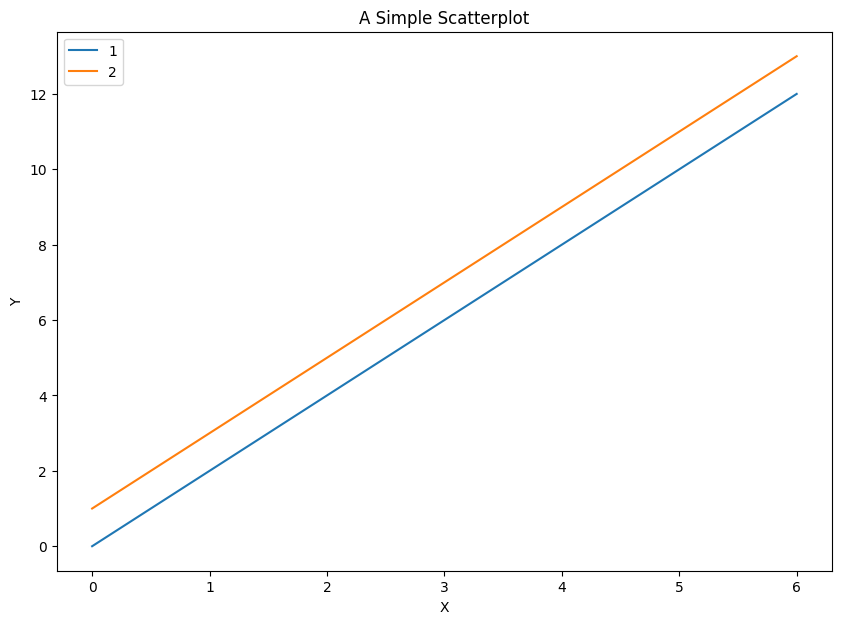

In [62]:
fig, ax = plt.subplots(1,1,figsize=(10, 7))  # (width, height); Durch das OO API-Interface
xx = np.linspace(0, 6, 100)
yy = xx*2

ax.plot(xx, yy, label="1")  # green dots
ax.plot(xx, yy+1, label="2")  # blue stars

#plt.xlim(0,6)
#plt.ylim(0,12)
#ax.set_xlim(0, 6) # x axis limits
#ax.set_ylim(0, 12) # y axis limits

ax.set_title("A Simple Scatterplot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.show()

## .scatter

In addition to the regular `plot` method, there are a number of other functions for generating different kind of plots: for example, the `scatter` method.

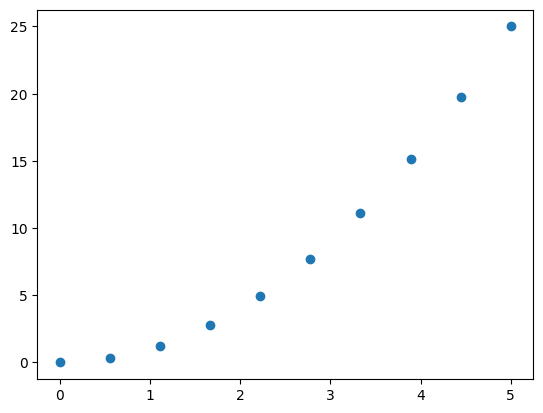

In [64]:
fig, ax = plt.subplots()
ax.scatter(x, x**2)
plt.show()

How is this different from a scatterplot drawn with `plot`?

The difference is `plt.plot()` does not provide options to change the color and size of point dynamically (based on another array).
`plt.scatter()` allows you to do that.

By varying the size and color of points, you can create (for example) nice looking bubble plots.

Another convenience is that you can directly use a Pandas dataframe to set the x and y values, provided you specify the source dataframe in the `data` argument.

You can also set the color 'c' and size 's' of the points from one of the dataframe columns itself.

In [65]:
import pandas as pd

midwest = pd.read_csv(
    "https://raw.githubusercontent.com/selva86/datasets/master/midwest_filter.csv"
)
midwest.head()

,PID,county,state,area,poptotal,popdensity,popwhite,popblack,popamerindian,popasian,...,percprof,poppovertyknown,percpovertyknown,percbelowpoverty,percchildbelowpovert,percadultpoverty,percelderlypoverty,inmetro,category,dot_size
0,561,ADAMS,IL,0.052,66090,1270.961540,63917,1702,98,249,...,4.355859,63628,96.274777,13.151443,18.011717,11.009776,12.443812,0,AAR,250.944411
1,562,ALEXANDER,IL,0.014,10626,759.000000,7054,3496,19,48,...,2.870315,10529,99.087145,32.244278,45.826514,27.385647,25.228976,0,LHR,185.781260
2,563,BOND,IL,0.022,14991,681.409091,14477,429,35,16,...,4.488572,14235,94.956974,12.068844,14.036061,10.852090,12.697410,0,AAR,175.905385
3,564,BOONE,IL,0.017,30806,1812.117650,29344,127,46,150,...,4.197800,30337,98.477569,7.209019,11.179536,5.536013,6.217047,1,ALU,319.823487
4,565,BROWN,IL,0.018,5836,324.222222,5264,547,14,5,...,3.367680,4815,82.505140,13.520249,13.022889,11.143211,19.200000,0,AAR,130.442161


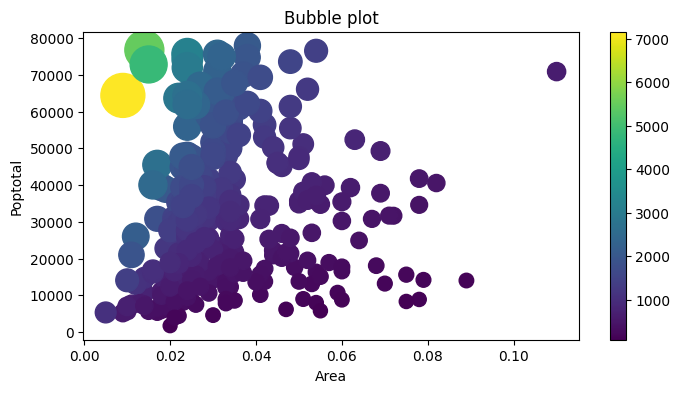

In [66]:
# Scatterplot with varying size and color of points
fig = plt.figure(figsize=(8, 4))

plt.scatter("area", "poptotal", data=midwest, s="dot_size", c="popdensity")
plt.title("Bubble plot")
plt.xlabel("Area")
plt.ylabel("Poptotal")
plt.colorbar()
plt.show()

## .legend

Legends for curves in a figure can be added in two ways. One method is to use the `legend` method of the axis object and pass a list/tuple of legend texts for the previously defined curves:

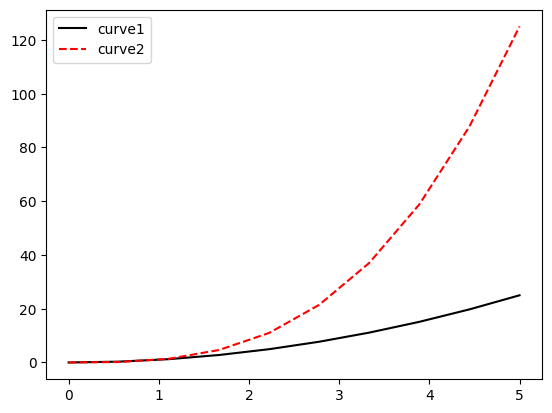

In [67]:
x = np.linspace(0, 5, 10)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(x, x**2, color="black")
ax.plot(x, x**3, color="red", linestyle="dashed")
ax.legend(["curve1", "curve2"])
plt.show()



This method is somewhat prone to errors and unflexible if curves are added to or removed from the figure (resulting in a wrongly labelled curve).

A better method is to use the `label="label text"` keyword argument when plots or other objects are added to the figure, and then using the `legend` method without arguments to add the legend to the figure:

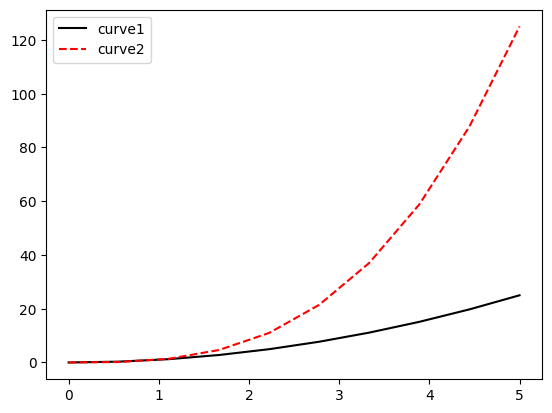

In [68]:
fig, ax = plt.subplots()

ax.plot(x, x**2, color="black", label="curve1")
ax.plot(x, x**3, color="red", linestyle="dashed", label="curve2")
ax.legend()
plt.show()

The advantage with this method is that if curves are added or removed from the figure, the legend is automatically updated accordingly.

The `legend` function takes an optional keyword argument `loc` that can be used to specify where in the figure the legend is to be drawn. The allowed values of `loc` are numerical codes for the various places the legend can be drawn. See http://matplotlib.org/users/legend_guide.html#legend-location for details. Some of the most common `loc` values are:

```
ax.legend(loc=0) # (default) let matplotlib decide the optimal location
ax.legend(loc=1) # upper right corner
ax.legend(loc=2) # upper left corner
ax.legend(loc=3) # lower left corner
ax.legend(loc=4) # lower right corner
# .. many more options are available
```

The following figure shows how to use the figure title, axis labels and legends described above:

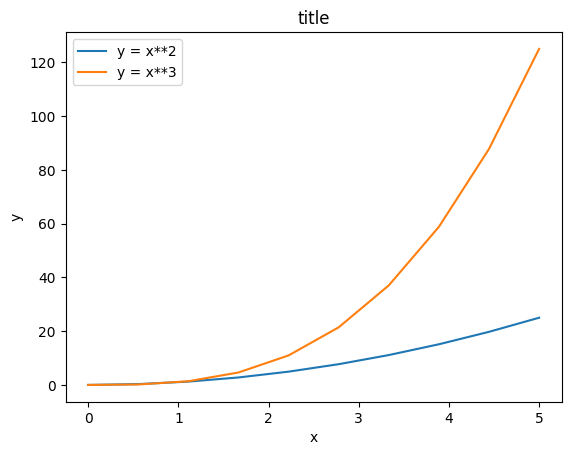

In [69]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label="y = x**2")
ax.plot(x, x**3, label="y = x**3")
ax.legend(loc=2) # upper left corner
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('title')

plt.show()

## Formatting: LaTeX, rcParams, plot styles


Matplotlib has great support for LaTeX. All we need to do is to use dollar signs to encapsulate LaTeX equations in any text (legend, title, label, etc.). For example, `"$y=x^3$"`.

But here we can run into a slightly subtle problem with LaTeX code and Python text strings. In LaTeX, we frequently use the backslash in commands, for example `\alpha` to produce the symbol $\alpha$. But the backslash already has a meaning in Python strings (the escape code character). To avoid Python messing up our latex code, we need to use "raw" text strings. Raw text strings are prepended with an '`r`', like `r"\alpha"` or `r'\alpha'` instead of `"\alpha"` or `'\alpha'`.

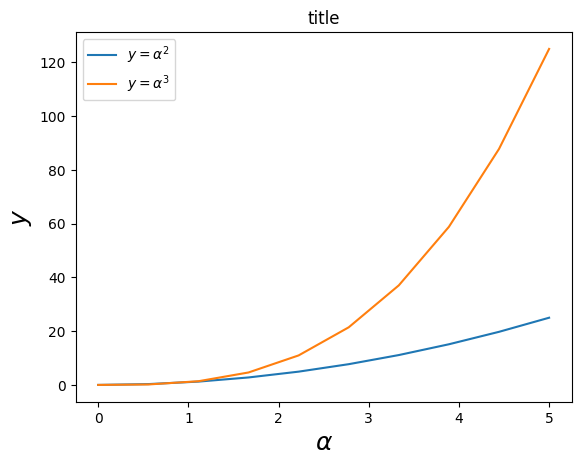

In [70]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title')

plt.show()

The look and feel of various components of a matplotlib plot can be set globally using *rcParams*.

The complete list of rcParams is very exhaustive: see the [help page](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#matplotlib.rcParams) for the full list and explanation.
You can also view it by typing:

In [71]:
import matplotlib as mpl
mpl.rc_params()

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

You can dynamically adjust the params you'd like to change by updating it at runtime.
For example, the below snippet adjusts the font by setting it to ['stix'](https://www.stixfonts.org/), which is a good choice since it looks great on plots.

In [72]:
mpl.rcParams.update({'font.size': 18,
                     'font.family': 'STIXGeneral',
                     'mathtext.fontset': 'stix'})

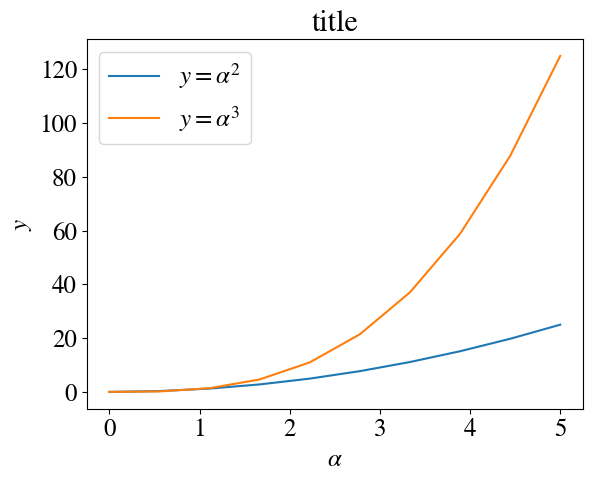

In [73]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title')

plt.show()

After modifying a plot, you can rollback the rcParams to default setting using:

In [74]:
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults

This looks more convenient than R's way to deal with graphical parameters (`op <- par(mfrow=(2,1); ...; par(op))`)

Matplotlib comes with **pre-built styles** that you can browse by typing:

In [75]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

Notice `fivethirtyeight`, and `ggplot`.

`seaborn` is called after another high-level plotting library that is especially useful if your input is in a Pandas dataframe. Note however that the seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn.

Let's play with some of the pre-built styles by creating a function that takes a style name as input and produces a plot with sine and cosine waves.

In [76]:
# our custom function
def plot_sine_cosine_wave(style="ggplot"):
    mpl.rcParams.update(mpl.rcParamsDefault)
    plt.style.use(style)

    X = np.linspace(0, 2 * np.pi, 100)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
    ax.plot(X, np.sin(X))
    ax.plot(X, np.cos(X))
    ax.set(xlabel="x (radians)", ylabel="y", title=style)
    plt.show()
    mpl.rcParams.update(mpl.rcParamsDefault)

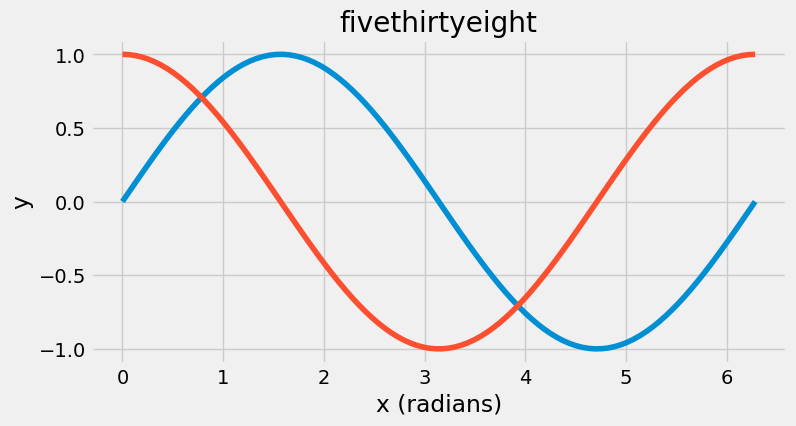

In [77]:
plot_sine_cosine_wave("fivethirtyeight")

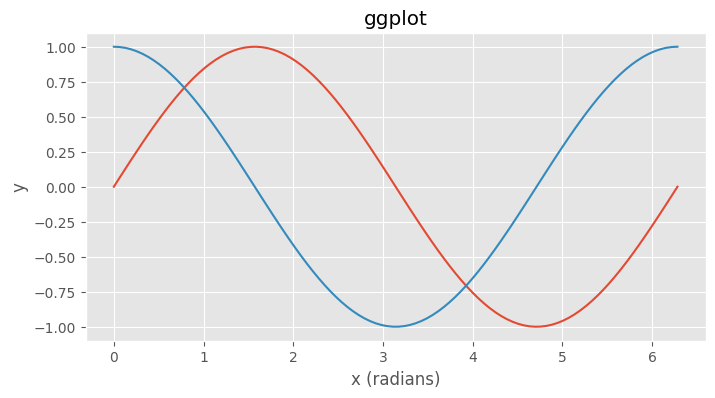

In [78]:
plot_sine_cosine_wave("ggplot")

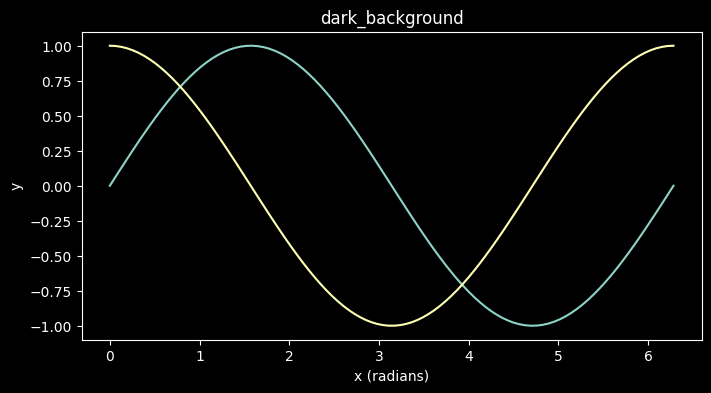

In [79]:
plot_sine_cosine_wave("dark_background")

## .plot() : Colors, line widths, line types

We have already seen that we can define markers, colors, and line types with a `format` string such as `og-.` (green circles with dash-dot line).

You can also set these properties separately using appropriate keywork arguments inside `plot`.
 
 **Colors**

Define colors by their names or RGB hex codes and optionally provide an alpha value using the `color` and `alpha` keyword arguments:

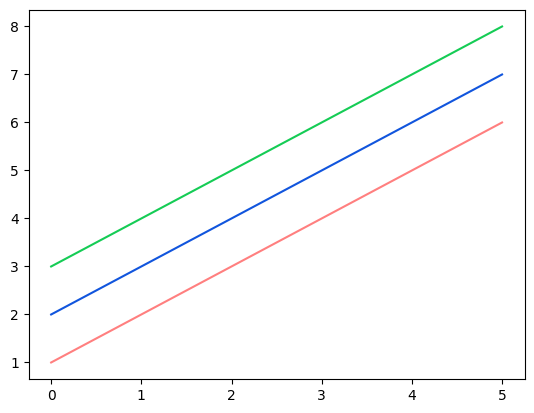

In [80]:
fig, ax = plt.subplots()

x = np.linspace(0, 5, 10)

ax.plot(x, x+1, color="red", alpha=0.5) # half-transparant red
ax.plot(x, x+2, color="#1155dd") # bluish color
ax.plot(x, x+3, color="#15cc55") # greenish color
plt.show()

Matplotlib also comes with **pre-built colors and palettes**. Type the following in your jupyter/python console to check out the available colors.

In [81]:
# View Colors
mpl.colors.CSS4_COLORS  # 148 colors

{'aliceblue': '#F0F8FF',
 'antiquewhite': '#FAEBD7',
 'aqua': '#00FFFF',
 'aquamarine': '#7FFFD4',
 'azure': '#F0FFFF',
 'beige': '#F5F5DC',
 'bisque': '#FFE4C4',
 'black': '#000000',
 'blanchedalmond': '#FFEBCD',
 'blue': '#0000FF',
 'blueviolet': '#8A2BE2',
 'brown': '#A52A2A',
 'burlywood': '#DEB887',
 'cadetblue': '#5F9EA0',
 'chartreuse': '#7FFF00',
 'chocolate': '#D2691E',
 'coral': '#FF7F50',
 'cornflowerblue': '#6495ED',
 'cornsilk': '#FFF8DC',
 'crimson': '#DC143C',
 'cyan': '#00FFFF',
 'darkblue': '#00008B',
 'darkcyan': '#008B8B',
 'darkgoldenrod': '#B8860B',
 'darkgray': '#A9A9A9',
 'darkgreen': '#006400',
 'darkgrey': '#A9A9A9',
 'darkkhaki': '#BDB76B',
 'darkmagenta': '#8B008B',
 'darkolivegreen': '#556B2F',
 'darkorange': '#FF8C00',
 'darkorchid': '#9932CC',
 'darkred': '#8B0000',
 'darksalmon': '#E9967A',
 'darkseagreen': '#8FBC8F',
 'darkslateblue': '#483D8B',
 'darkslategray': '#2F4F4F',
 'darkslategrey': '#2F4F4F',
 'darkturquoise': '#00CED1',
 'darkviolet': '#9400D3

In [82]:
mpl.colors.XKCD_COLORS  # 949 colors

{'xkcd:cloudy blue': '#acc2d9',
 'xkcd:dark pastel green': '#56ae57',
 'xkcd:dust': '#b2996e',
 'xkcd:electric lime': '#a8ff04',
 'xkcd:fresh green': '#69d84f',
 'xkcd:light eggplant': '#894585',
 'xkcd:nasty green': '#70b23f',
 'xkcd:really light blue': '#d4ffff',
 'xkcd:tea': '#65ab7c',
 'xkcd:warm purple': '#952e8f',
 'xkcd:yellowish tan': '#fcfc81',
 'xkcd:cement': '#a5a391',
 'xkcd:dark grass green': '#388004',
 'xkcd:dusty teal': '#4c9085',
 'xkcd:grey teal': '#5e9b8a',
 'xkcd:macaroni and cheese': '#efb435',
 'xkcd:pinkish tan': '#d99b82',
 'xkcd:spruce': '#0a5f38',
 'xkcd:strong blue': '#0c06f7',
 'xkcd:toxic green': '#61de2a',
 'xkcd:windows blue': '#3778bf',
 'xkcd:blue blue': '#2242c7',
 'xkcd:blue with a hint of purple': '#533cc6',
 'xkcd:booger': '#9bb53c',
 'xkcd:bright sea green': '#05ffa6',
 'xkcd:dark green blue': '#1f6357',
 'xkcd:deep turquoise': '#017374',
 'xkcd:green teal': '#0cb577',
 'xkcd:strong pink': '#ff0789',
 'xkcd:bland': '#afa88b',
 'xkcd:deep aqua': '#0

In [83]:
mpl.colors.BASE_COLORS  # 8 colors

{'b': (0, 0, 1),
 'g': (0, 0.5, 0),
 'r': (1, 0, 0),
 'c': (0, 0.75, 0.75),
 'm': (0.75, 0, 0.75),
 'y': (0.75, 0.75, 0),
 'k': (0, 0, 0),
 'w': (1, 1, 1)}

In [84]:
# View first 10 Palettes
dir(plt.cm)[:10]

['Accent',
 'Accent_r',
 'Blues',
 'Blues_r',
 'BrBG',
 'BrBG_r',
 'BuGn',
 'BuGn_r',
 'BuPu',
 'BuPu_r']

For more information and examples on Matplotlib's color palettes, have a look at the [official documentation](https://matplotlib.org/stable/gallery/color/colormap_reference.html).

## .plot(linestyle, marker, color, ...)

To change the line width, we can use the `linewidth` (or `lw`) keyword argument. The line style can be selected using the `linestyle` (or `ls`) keyword arguments:

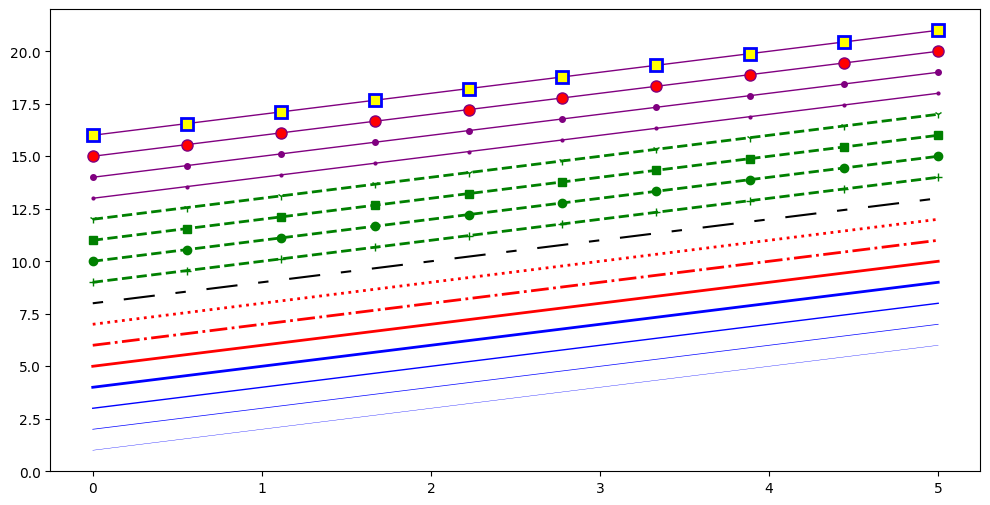

In [85]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x, x+1, color="blue", linewidth=0.25)
ax.plot(x, x+2, color="blue", linewidth=0.50)
ax.plot(x, x+3, color="blue", linewidth=1.00)
ax.plot(x, x+4, color="blue", linewidth=2.00)

# possible linestype options ‘-‘, ‘--’, ‘-.’, ‘:’, ‘steps’
ax.plot(x, x+5, color="red", lw=2, linestyle='-')
ax.plot(x, x+6, color="red", lw=2, ls='-.')
ax.plot(x, x+7, color="red", lw=2, ls=':')

# custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10]) # format: line length, space length, ...

# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="green", lw=2, ls='--', marker='+')
ax.plot(x, x+10, color="green", lw=2, ls='--', marker='o')
ax.plot(x, x+11, color="green", lw=2, ls='--', marker='s')
ax.plot(x, x+12, color="green", lw=2, ls='--', marker='1')

# marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8,
        markerfacecolor="yellow", markeredgewidth=2, markeredgecolor="blue")

plt.show()

**After title, legend and formatting of the .plot() method** : We will dive into the elements that are related to the Text (Artist). Like labels and then tick labels of the Axis